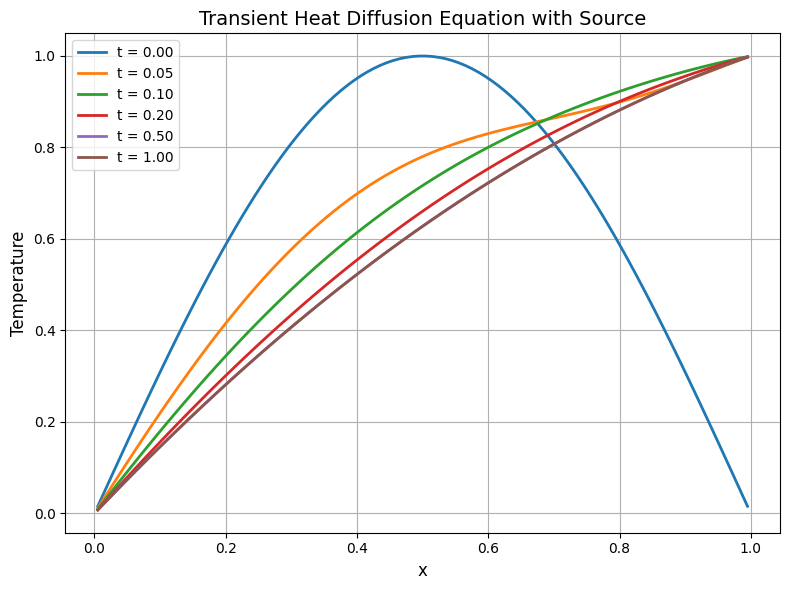

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from fipy import *

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)

alpha = 1.0      # Thermal diffusivity
S = 1.0          # Constant heat source
dt = 1e-2
final_time = 1.0
steps = int(final_time / dt)

T = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=0.0
)

x = mesh.cellCenters[0]

# Initial condition
T.setValue(np.sin(np.pi * x / L))

# BOUNDARY CONDITIONS
T.constrain(0.0, mesh.facesLeft)
T.constrain(1.0, mesh.facesRight)

# PDE :- ∂T/∂t = α ∂²T/∂x² + S
eq = (
    TransientTerm()
    == DiffusionTerm(coeff=alpha)
    + S
)

plot_times = [0.00, 0.05, 0.10, 0.20, 0.50, 1.00]
plot_steps = [int(round(t / dt)) for t in plot_times]

plt.figure(figsize=(8,6))

plt.plot(
    x.value,
    T.value,
    linewidth=2,
    label='t = 0.00'
)

for step in range(1, steps + 1):

    eq.solve(var=T, dt=dt)

    if step in plot_steps:

        plt.plot(
            x.value,
            T.value,
            linewidth=2,
            label=f't = {step*dt:.2f}'
        )

plt.xlabel("x", fontsize=12)
plt.ylabel("Temperature", fontsize=12)
plt.title("Transient Heat Diffusion Equation with Source", fontsize=14)

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Maximum Error = 1.250000e-05
L2 Error      = 1.250000e-05


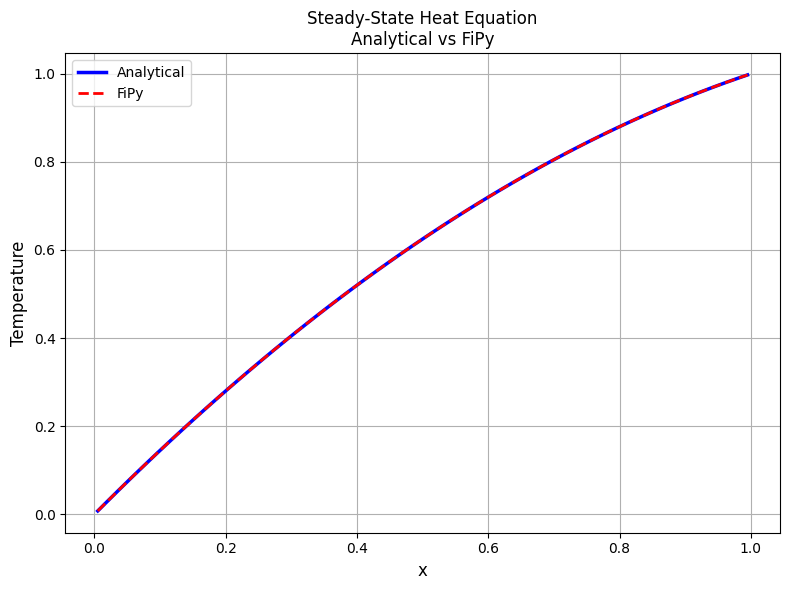

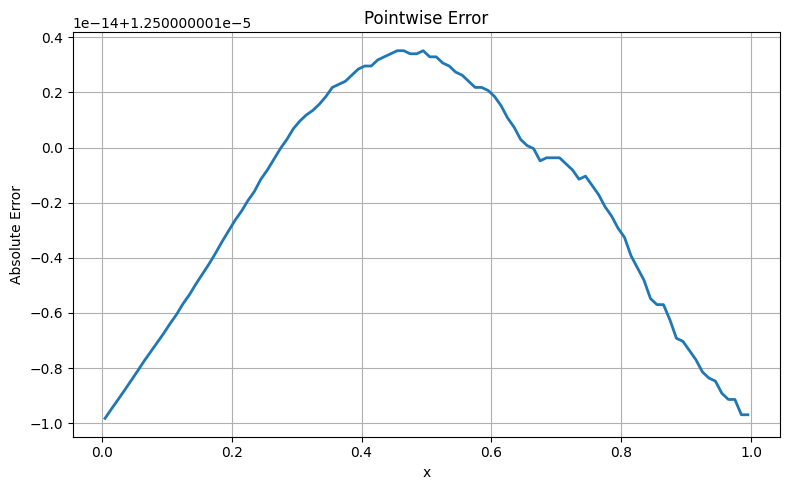

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from fipy import *

L = 1.0
nx = 100

mesh = Grid1D(nx=nx, dx=L/nx)

alpha = 1.0
S = 1.0

T = CellVariable(name="Temperature", mesh=mesh)

x = mesh.cellCenters[0]

# BOUNDARY CONDITIONS
T.constrain(0.0, mesh.facesLeft)
T.constrain(1.0, mesh.facesRight)

# STEADY-STATE EQUATION :- α d²T/dx² + S = 0
eq = (
    DiffusionTerm(coeff=alpha)
    + S
)
eq.solve(var=T)

# ANALYTICAL SOLUTION
T_exact = (
    -(S/(2*alpha))*x.value**2
    +
    ((1 + S*L**2/(2*alpha))/L)*x.value
)

# ERROR

error = np.abs(T.value - T_exact)

max_error = np.max(error)

l2_error = np.sqrt(np.mean(error**2))

print(f"Maximum Error = {max_error:.6e}")
print(f"L2 Error      = {l2_error:.6e}")

# ANALYTICAL vs FiPy

plt.figure(figsize=(8,6))

plt.plot(
    x.value,
    T_exact,
    'b-',
    linewidth=2.5,
    label='Analytical'
)

plt.plot(
    x.value,
    T.value,
    'r--',
    linewidth=2,
    label='FiPy'
)

plt.xlabel("x", fontsize=12)
plt.ylabel("Temperature", fontsize=12)
plt.title("Steady-State Heat Equation\nAnalytical vs FiPy")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# ERROR PLOT

plt.figure(figsize=(8,5))

plt.plot(
    x.value,
    error,
    linewidth=2
)

plt.xlabel("x")
plt.ylabel("Absolute Error")
plt.title("Pointwise Error")

plt.grid(True)

plt.tight_layout()
plt.show()

Maximum Error = 1.250000e-05
L2 Error      = 1.250000e-05


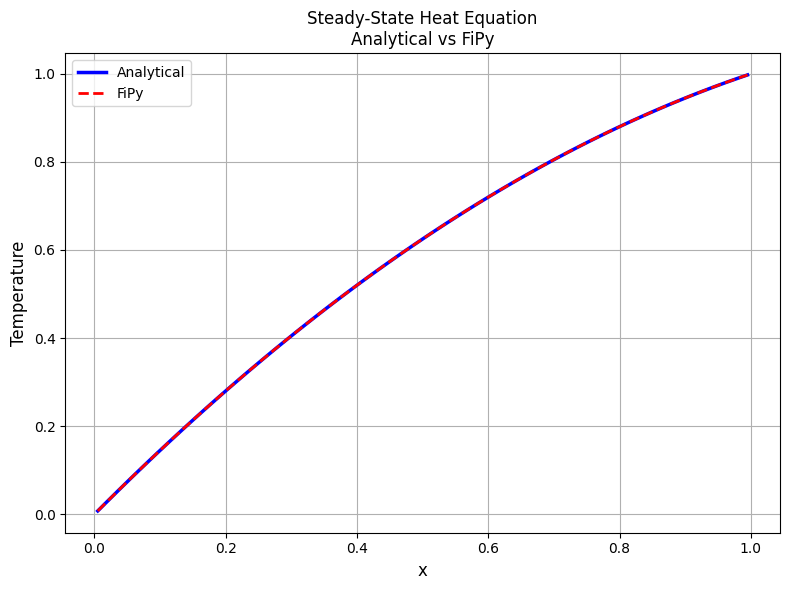

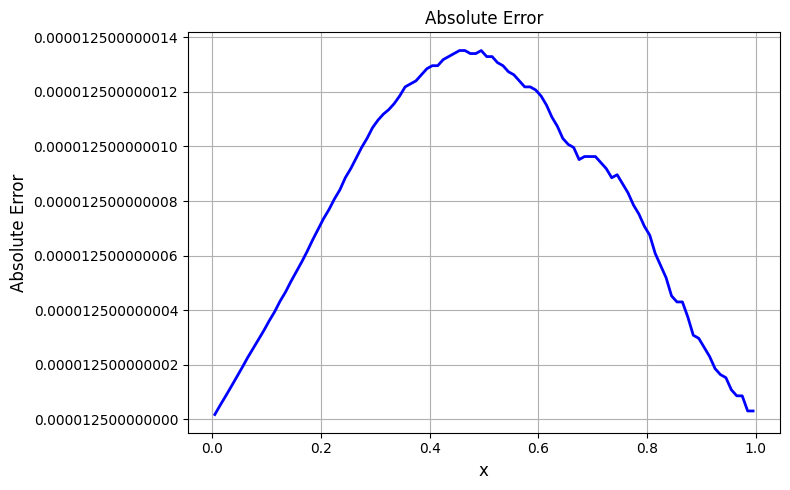

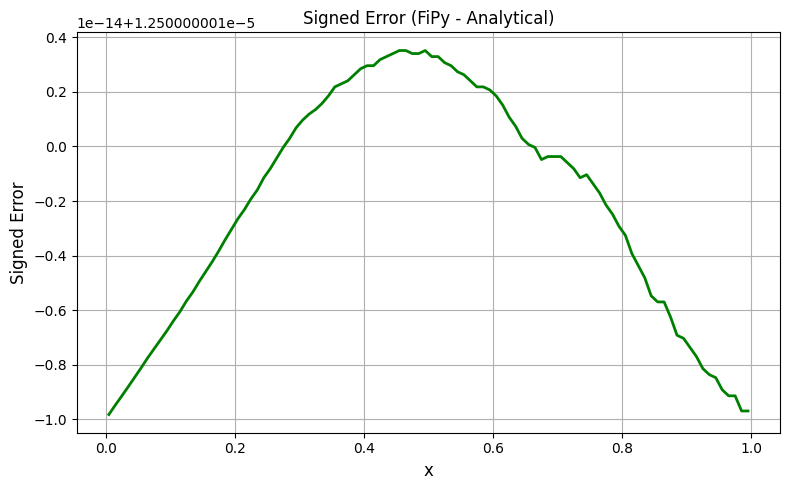

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from fipy import *


L = 1.0
nx = 100

mesh = Grid1D(nx=nx, dx=L/nx)

alpha = 1.0
S = 1.0

T = CellVariable(name="Temperature", mesh=mesh)

x = mesh.cellCenters[0]

# BOUNDARY CONDITIONS

T.constrain(0.0, mesh.facesLeft)
T.constrain(1.0, mesh.facesRight)

# STEADY-STATE EQUATION :- α d²T/dx² + S = 0

eq = (
    DiffusionTerm(coeff=alpha)
    + S
)

eq.solve(var=T)

# ANALYTICAL SOLUTION :- T(x) = -(S/(2α))x² + ((1 + SL²/(2α))/L)x

T_exact = (
    -(S / (2 * alpha)) * x.value**2
    + ((1 + S * L**2 / (2 * alpha)) / L) * x.value
)

# ERROR CALCULATION

signed_error = T.value - T_exact
abs_error = np.abs(signed_error)

max_error = np.max(abs_error)
l2_error = np.sqrt(np.mean(abs_error**2))

print(f"Maximum Error = {max_error:.6e}")
print(f"L2 Error      = {l2_error:.6e}")

# ANALYTICAL vs FiPy

plt.figure(figsize=(8,6))

plt.plot(
    x.value,
    T_exact,
    'b-',
    linewidth=2.5,
    label='Analytical'
)

plt.plot(
    x.value,
    T.value,
    'r--',
    linewidth=2,
    label='FiPy'
)

plt.xlabel("x", fontsize=12)
plt.ylabel("Temperature", fontsize=12)
plt.title("Steady-State Heat Equation\nAnalytical vs FiPy")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# ABSOLUTE ERROR

plt.figure(figsize=(8,5))

plt.plot(
    x.value,
    abs_error,
    linewidth=2,
    color='blue'
)

plt.xlabel("x", fontsize=12)
plt.ylabel("Absolute Error", fontsize=12)
plt.title("Absolute Error")

plt.grid(True)

# Disable offset notation
plt.ticklabel_format(axis='y', style='plain', useOffset=False)

plt.tight_layout()
plt.show()

# SIGNED ERROR

plt.figure(figsize=(8,5))

plt.plot(
    x.value,
    signed_error,
    linewidth=2,
    color='green'
)

plt.xlabel("x", fontsize=12)
plt.ylabel("Signed Error", fontsize=12)
plt.title("Signed Error (FiPy - Analytical)")

plt.grid(True)

plt.ticklabel_format(axis='y', style='scientific', scilimits=(0,0))

plt.tight_layout()
plt.show()

alpha = 1.0
S = 1.0

Maximum Error = 2.688508e-03
L2 Error      = 1.898890e-03


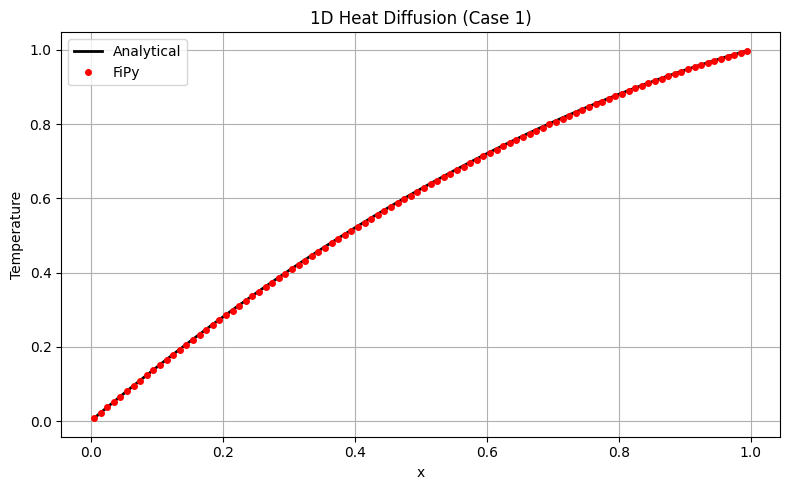

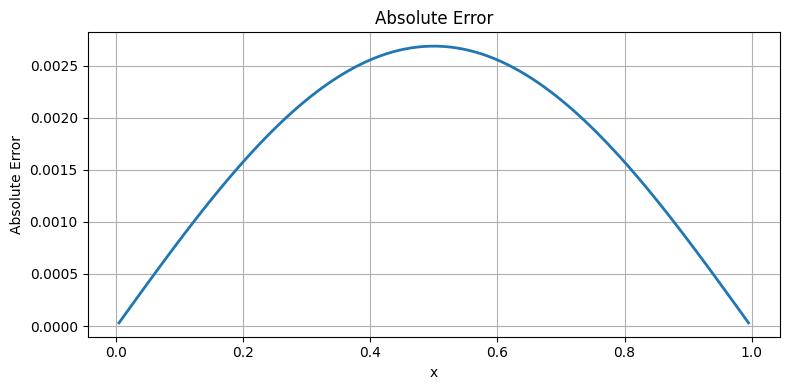

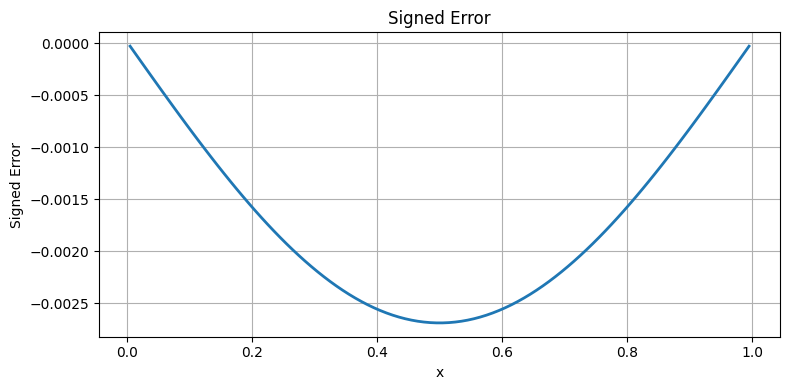

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)

# Convert to NumPy array
x = mesh.cellCenters[0].value

# PHYSICAL PARAMETERS (CASE 1) :- rho*Cp*dT/dt = k*d²T/dx² + Q

k = 1.0          # Thermal conductivity
rho = 1.0        # Density
Cp = 1.0         # Specific heat
Q = 1.0          # Heat generation
J = 1.0          # Current density
E = 1.0          # Electric field

# Derived parameters

alpha = k / (rho * Cp)
S = J * E / (rho * Cp)

print(f"alpha = {alpha}")
print(f"S = {S}")

dt = 1e-2
final_time = 10.0
steps = int(final_time / dt)

T = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=0.0
)

# BOUNDARY CONDITIONS
T.constrain(0.0, mesh.facesLeft)
T.constrain(1.0, mesh.facesRight)

# GOVERNING EQUATION :- dT/dt = alpha*d²T/dx² + S
eq = (
    TransientTerm()
    == DiffusionTerm(coeff=alpha)
    + S
)

# TRANSIENT SOLUTION
for step in range(steps):
    eq.solve(var=T, dt=dt)

# ANALYTICAL STEADY-STATE SOLUTION
T_exact = (
    -(S / (2 * alpha)) * x**2
    + ((1 + S * L**2 / (2 * alpha)) / L) * x
)

# ERROR ANALYSIS

numerical = T.value

abs_error = np.abs(numerical - T_exact)
signed_error = numerical - T_exact

max_error = np.max(abs_error)
l2_error = np.sqrt(np.mean(abs_error**2))

print(f"\nMaximum Error = {max_error:.6e}")
print(f"L2 Error      = {l2_error:.6e}")

plt.figure(figsize=(8,5))
plt.plot(x, T_exact, 'k-', linewidth=2, label='Analytical')
plt.plot(x, numerical, 'ro', markersize=4, label='FiPy')
plt.xlabel("x")
plt.ylabel("Temperature")
plt.title("1D Heat Diffusion (Case 1)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(x, abs_error, linewidth=2)
plt.xlabel("x")
plt.ylabel("Absolute Error")
plt.title("Absolute Error")
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(x, signed_error, linewidth=2)
plt.xlabel("x")
plt.ylabel("Signed Error")
plt.title("Signed Error")
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

alpha = 1.0
S = 1.0

Maximum Error = 1.250000e-05
L2 Error      = 1.250000e-05


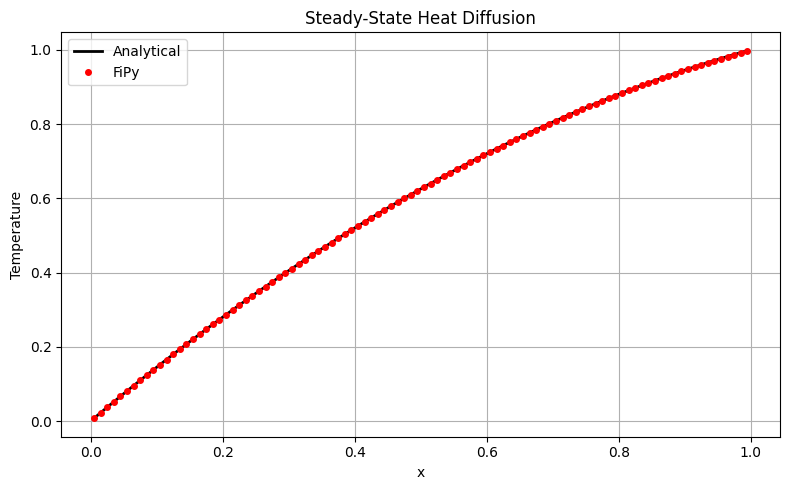

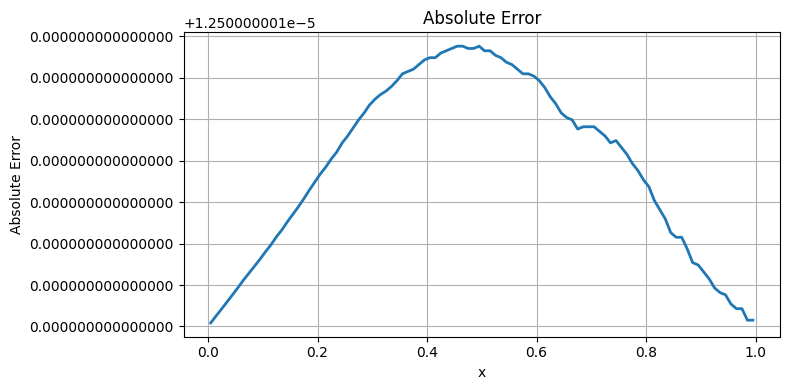

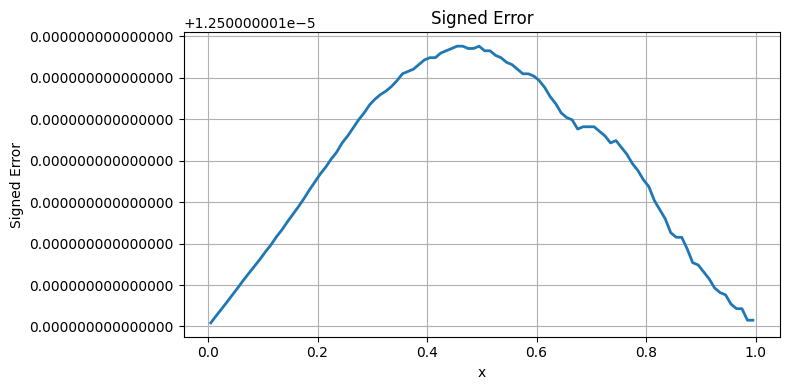

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from fipy import CellVariable, Grid1D, DiffusionTerm

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
x = mesh.cellCenters[0].value

k = 1.0
rho = 1.0
Cp = 1.0
J = 1.0
E = 1.0

alpha = k / (rho * Cp)
S = J * E / (rho * Cp)

print(f"alpha = {alpha}")
print(f"S = {S}")

# TEMPERATURE VARIABLE

T = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=0.0
)

# BOUNDARY CONDITIONS
T.constrain(0.0, mesh.facesLeft)
T.constrain(1.0, mesh.facesRight)

# STEADY-STATE EQUATION :- alpha*d²T/dx² + S = 0
eq = (
    DiffusionTerm(coeff=alpha)
    + S
)
eq.solve(var=T)

# ANALYTICAL SOLUTION :- T(x)=-(S/2α)x² + (1+SL²/(2α))x/L
T_exact = (
    -(S / (2 * alpha)) * x**2
    + ((1 + (S * L**2) / (2 * alpha)) / L) * x
)


# ERROR ANALYSIS

numerical = T.value

signed_error = numerical - T_exact
abs_error = np.abs(signed_error)

max_error = np.max(abs_error)
l2_error = np.sqrt(np.mean(abs_error**2))

print(f"\nMaximum Error = {max_error:.6e}")
print(f"L2 Error      = {l2_error:.6e}")

plt.figure(figsize=(8,5))

plt.plot(
    x,
    T_exact,
    'k-',
    linewidth=2,
    label='Analytical'
)

plt.plot(
    x,
    numerical,
    'ro',
    markersize=4,
    label='FiPy'
)

plt.xlabel("x")
plt.ylabel("Temperature")
plt.title("Steady-State Heat Diffusion")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ABSOLUTE ERROR

plt.figure(figsize=(8,4))

plt.plot(
    x,
    abs_error,
    linewidth=2
)

plt.xlabel("x")
plt.ylabel("Absolute Error")
plt.title("Absolute Error")
plt.grid(True)

plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

# SIGNED ERROR

plt.figure(figsize=(8,4))

plt.plot(
    x,
    signed_error,
    linewidth=2
)

plt.xlabel("x")
plt.ylabel("Signed Error")
plt.title("Signed Error")
plt.grid(True)

plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()